# 02 RNN Basics

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build a simple RNN (or LSTM) and process a **sequence** (e.g. text or time steps)
- Train it on a small sequence task (e.g. sentiment or next-step prediction) and see loss/accuracy
- Understand why we use an RNN instead of a plain feedforward NN for sequences

---

## 🌍 Real life

**Where is this used?** RNNs are used for **text classification**, **time series**, **speech**, and **translation** when **order matters**.

**In this notebook we use** an **RNN** to process a **sequence** (e.g. padded word indices) and produce a single output (e.g. sentiment). We use an **RNN** (instead of a plain NN that sees all tokens at once) **because** **order matters**; the RNN processes step by step and keeps a **hidden state** that carries information forward.

**📌 Covers slide(s):** **17** — RNNs, vanishing/exploding gradients. *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below.

## Theory (short)

- **RNN:** At each time step t, it takes **input x_t** and **previous hidden state h_{t-1}**, and outputs **new hidden state h_t** (and optionally output y_t). So it maintains **memory** along the sequence.
- **Why sequences?** For text, time series, or any ordered data, the **order** of elements matters; an RNN processes them in order and passes information forward.
- **SimpleRNN vs LSTM:** SimpleRNN can suffer from vanishing gradients on long sequences; LSTM uses gates to control what to remember/forget. We use LSTM here for stability.
- **We use RNN** instead of a plain NN because a plain NN would treat the sequence as a flat bag of inputs and lose order.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy. We use a small text dataset (e.g. IMDB subset) or a synthetic sequence so the notebook runs in ~10 min.

**Dataset:** Real — IMDB (movie reviews, sentiment).

**Outputs:** Training/validation loss and accuracy (with axis labels), test accuracy, and a short "what you did" summary.

## Step 1: Imports and load a small sequence dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    (x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=2000)
    maxlen = 80
    x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen, padding="post", truncating="post")
    x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen, padding="post", truncating="post")
    x_train, y_train = x_train[:2000], y_train[:2000]
    x_test, y_test = x_test[:500], y_test[:500]
    print("Train:", x_train.shape, "Test:", x_test.shape)
else:
    print("Install TensorFlow: pip install tensorflow")

Train: (2000, 80) Test: (500, 80)


## Step 2: Build RNN model (we use LSTM instead of SimpleRNN for better gradient flow on sequences)

In [2]:
if HAS_TF:
    model = keras.Sequential([
        keras.layers.Embedding(2000, 32, input_length=maxlen),
        keras.layers.LSTM(32),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    model.summary()

/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Step 3: Train (2 epochs so it runs quickly)

In [3]:
if HAS_TF:
    history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=2, batch_size=64, verbose=1)

Epoch 1/2


 1/32 ━━━━━━━━━━━━━━━━━━━━ 27s 875ms/step - accuracy: 0.5000 - loss: 0.6930

 6/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4940 - loss: 0.6933  

 9/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4897 - loss: 0.6934

15/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4933 - loss: 0.6934

...

 8/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5806 - loss: 0.6899 

15/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5645 - loss: 0.6890

22/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5539 - loss: 0.6885

29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5513 - loss: 0.6877

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5455 - loss: 0.6852 - val_accuracy: 0.5720 - val_loss: 0.6901


## Step 4: Plot loss and accuracy

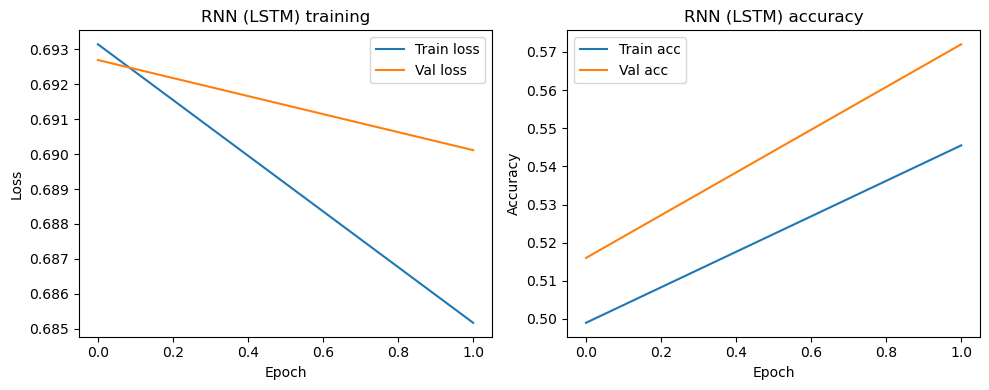

Test accuracy: 0.5720


In [4]:
if HAS_TF:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.plot(history.history["loss"], label="Train loss")
    ax1.plot(history.history["val_loss"], label="Val loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("RNN (LSTM) training")
    ax1.legend()
    ax2.plot(history.history["accuracy"], label="Train acc")
    ax2.plot(history.history["val_accuracy"], label="Val acc")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("RNN (LSTM) accuracy")
    ax2.legend()
    plt.tight_layout()
    plt.show()
    _, acc = model.evaluate(x_test, y_test, verbose=0)
    print("Test accuracy: %.4f" % acc)

## 🌍 Real-World Worked Example — Stock Price Trend Prediction

**Industry context:** Hedge funds and trading platforms use LSTM models to predict price trends.  
Bloomberg Terminal, QuantConnect, and many hedge funds use sequence models for finance.

We use an LSTM to predict whether a **synthetic stock price** will go up or down next day.

In [ ]:
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt

# ── Generate realistic stock-like price series ─────────────────────────────
np.random.seed(42)
n = 1000
price = np.cumsum(np.random.randn(n) * 0.5 + 0.05).astype(np.float32)  # random walk

# Create sequences: use 20 days to predict direction on day 21
SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(price) - SEQ_LEN - 1):
    X_list.append(price[i:i+SEQ_LEN])
    y_list.append(1 if price[i+SEQ_LEN] > price[i+SEQ_LEN-1] else 0)

X_arr = np.array(X_list); y_arr = np.array(y_list)
# Normalise each sequence
X_arr = (X_arr - X_arr.mean(1,keepdims=True)) / (X_arr.std(1,keepdims=True)+1e-8)

split = int(0.8*len(X_arr))
Xtr = torch.tensor(X_arr[:split]).unsqueeze(-1)  # (N, 20, 1)
Ytr = torch.tensor(y_arr[:split], dtype=torch.long)
Xte = torch.tensor(X_arr[split:]).unsqueeze(-1)
Yte = torch.tensor(y_arr[split:], dtype=torch.long)

# ── LSTM Model ────────────────────────────────────────────────────────────
class TrendLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, batch_first=True, num_layers=2, dropout=0.2)
        self.fc   = nn.Linear(32, 2)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])   # last time step

model   = TrendLSTM()
opt     = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
losses  = []

for epoch in range(60):
    model.train()
    loss = loss_fn(model(Xtr), Ytr)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

model.eval()
with torch.no_grad():
    acc = (model(Xte).argmax(1)==Yte).float().mean().item()
print(f"Direction prediction accuracy: {acc*100:.1f}%")
print("(Random chance = 50%. Production models target 55-60% for profitable trading.)")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(price[:200]); plt.title("Synthetic Stock Price (200 days)"); plt.xlabel("Day"); plt.ylabel("Price")
plt.subplot(1,2,2)
plt.plot(losses); plt.title("LSTM Training Loss"); plt.xlabel("Epoch")
plt.tight_layout(); plt.show()

## 🧩 Mini-exercise

**Try it (choose one):** Change the number of LSTM units (e.g. 32 → 64) and retrain for 1 epoch. Does loss go down faster? Or reduce the embedding dimension and see how it affects accuracy.

---

## ✅ Summary

**What you did:** Built an RNN (LSTM) for sequence classification (IMDB sentiment), trained it for 2 epochs, and plotted loss/accuracy.

**In real life you'd also:** Use longer sequences, more data, and tune embedding size and LSTM units.

**The main idea:** RNNs process sequences step by step and keep a hidden state; we use them (instead of a plain NN) when **order matters**.

**Next:** `03_lstm_advanced` goes deeper into LSTM/GRU; `04_transformer_attention` introduces attention and transformers.

## 📚 References & Further Reading

**Papers:**
- Hochreiter & Schmidhuber (1997) — [Long Short-Term Memory](https://www.bioinf.jku.at/publications/older/2604.pdf)
- Cho et al. (2014) — [GRU: Learning Phrase Representations](https://arxiv.org/abs/1406.1078)

**PyTorch Docs:** [torch.nn.LSTM](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)

**State-of-the-Art:** LSTMs are still widely used in production for:
- Time series forecasting (Bloomberg, Reuters)
- Speech recognition in embedded systems (no internet)